# Heart Disease Prediction - Complete Machine Learning Project


This notebook builds a complete end-to-end Machine Learning project for predicting cardiovascular disease

### Project Goal
Use patient information such as age, blood pressure, cholesterol, glucose, lifestyle habits, height, and weight to predict whether a patient has cardiovascular disease.

### Target Variable
The target column is `cardio`.

- `0` = no cardiovascular disease
- `1` = cardiovascular disease


# 1. Import Libraries and Set Up the Notebook

We import libraries for data analysis, visualization, preprocessing, model training, evaluation, tuning, and model saving.


In [1]:
# Basic project setup
from pathlib import Path
import os
import warnings

PROJECT_DIR = Path.cwd()
os.environ["MPLCONFIGDIR"] = str(PROJECT_DIR / ".matplotlib_cache")
warnings.filterwarnings("ignore")

# Data analysis libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
)

# Model saving library
import joblib

# Notebook display tools
from IPython.display import display, Markdown

# Display and plot settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["font.size"] = 11

# Fixed random state gives reproducible results.
RANDOM_STATE = 42

print("All libraries imported successfully.")
print(f"Project directory: {PROJECT_DIR}")


All libraries imported successfully.
Project directory: /Users/jeevraj/Desktop/AI Cardiovascular Disease Analysis


# 2. Load the Dataset

The CSV file is separated by semicolons (`;`), so we use `sep=';'` when reading it with pandas.


In [2]:
# Dataset path inside the project folder
DATA_PATH = PROJECT_DIR / "data" / "cardio_train.csv"

# Backup path from the original user-provided location
ORIGINAL_DATA_PATH = Path("/Users/jeevraj/Desktop/Heart Project/cardio_train.csv")

# Use the project copy if it exists. Otherwise, use the original path.
if DATA_PATH.exists():
    dataset_path = DATA_PATH
elif ORIGINAL_DATA_PATH.exists():
    dataset_path = ORIGINAL_DATA_PATH
else:
    raise FileNotFoundError("cardio_train.csv was not found. Please place it in the data folder.")

# Load the dataset using the correct separator.
df_raw = pd.read_csv(dataset_path, sep=";")

print(f"Dataset loaded from: {dataset_path}")
print(f"Rows: {df_raw.shape[0]}")
print(f"Columns: {df_raw.shape[1]}")


Dataset loaded from: /Users/jeevraj/Desktop/AI Cardiovascular Disease Analysis/data/cardio_train.csv
Rows: 70000
Columns: 13


# 3. Dataset Understanding

Before cleaning or modeling, we inspect the dataset carefully. This helps us understand the structure, columns, data types, and summary statistics.


In [3]:
# Display first and last rows.
display(Markdown("### First 5 Rows"))
display(df_raw.head())

display(Markdown("### Last 5 Rows"))
display(df_raw.tail())

# Display shape and columns.
print("Dataset shape:", df_raw.shape)
print("\nColumn names:")
print(list(df_raw.columns))

# Display data types.
display(Markdown("### Data Types"))
display(df_raw.dtypes.to_frame(name="Data Type"))


### First 5 Rows

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.000,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.000,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.000,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.000,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.000,100,60,1,1,0,0,0,0


### Last 5 Rows

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
69995,99993,19240,2,168,76.000,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.000,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.000,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.000,135,80,1,2,0,0,0,1
69999,99999,20540,1,170,72.000,120,80,2,1,0,0,1,0


Dataset shape: (70000, 13)

Column names:
['id', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']


### Data Types

,Data Type
id,int64
age,int64
gender,int64
height,int64
weight,float64
ap_hi,int64
ap_lo,int64
cholesterol,int64
gluc,int64
smoke,int64


In [4]:
# info() shows non-null counts, data types, and memory usage.
print("Dataset information:")
df_raw.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [5]:
# Statistical summary for numeric columns.
display(Markdown("### Statistical Summary"))
display(df_raw.describe().T)

# Unique value count helps identify categorical columns.
display(Markdown("### Unique Values Per Column"))
display(df_raw.nunique().to_frame(name="Unique Values"))


### Statistical Summary

,count,mean,std,min,25%,50%,75%,max
id,70000.000,49972.420,28851.302,0.000,25006.750,50001.500,74889.250,99999.000
age,70000.000,19468.866,2467.252,10798.000,17664.000,19703.000,21327.000,23713.000
gender,70000.000,1.350,0.477,1.000,1.000,1.000,2.000,2.000
height,70000.000,164.359,8.210,55.000,159.000,165.000,170.000,250.000
weight,70000.000,74.206,14.396,10.000,65.000,72.000,82.000,200.000
ap_hi,70000.000,128.817,154.011,-150.000,120.000,120.000,140.000,16020.000
ap_lo,70000.000,96.630,188.473,-70.000,80.000,80.000,90.000,11000.000
cholesterol,70000.000,1.367,0.680,1.000,1.000,1.000,2.000,3.000
gluc,70000.000,1.226,0.572,1.000,1.000,1.000,1.000,3.000
smoke,70000.000,0.088,0.283,0.000,0.000,0.000,0.000,1.000


### Unique Values Per Column

,Unique Values
id,70000
age,8076
gender,2
height,109
weight,287
ap_hi,153
ap_lo,157
cholesterol,3
gluc,3
smoke,2


## Feature Explanation in Simple Language

| Column | Meaning | Simple Explanation |
|---|---|---|
| `id` | Patient ID | Unique number for each patient. It should not be used for prediction. |
| `age` | Age in days | We convert it into years to make it easier to understand. |
| `gender` | Gender code | Commonly documented as `1 = female`, `2 = male` for this dataset. |
| `height` | Height in centimeters | Patient height. |
| `weight` | Weight in kilograms | Patient weight. |
| `ap_hi` | Systolic blood pressure | The upper blood pressure number, such as 120 in 120/80. |
| `ap_lo` | Diastolic blood pressure | The lower blood pressure number, such as 80 in 120/80. |
| `cholesterol` | Cholesterol level | `1 = normal`, `2 = above normal`, `3 = well above normal`. |
| `gluc` | Glucose level | `1 = normal`, `2 = above normal`, `3 = well above normal`. |
| `smoke` | Smoking status | `0 = no`, `1 = yes`. |
| `alco` | Alcohol intake | `0 = no`, `1 = yes`. |
| `active` | Physical activity | `0 = not active`, `1 = active`. |
| `cardio` | Target variable | `0 = no disease`, `1 = disease`. |


# 4. Data Cleaning

We check for missing values, duplicate rows, invalid category values, inconsistent measurements, and outliers.


In [6]:
# Check missing values.
missing_values = df_raw.isna().sum()
missing_percent = (missing_values / len(df_raw)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": missing_percent,
})

display(missing_table)

if missing_values.sum() == 0:
    print("Insight: There are no missing values in this dataset.")
else:
    print("Insight: Missing values exist and should be handled before modeling.")


,Missing Values,Missing Percentage
id,0,0.000
age,0,0.000
gender,0,0.000
height,0,0.000
weight,0,0.000
ap_hi,0,0.000
ap_lo,0,0.000
cholesterol,0,0.000
gluc,0,0.000
smoke,0,0.000


Insight: There are no missing values in this dataset.


In [7]:
# Check duplicate rows.
exact_duplicates = df_raw.duplicated().sum()
clinical_columns = [column for column in df_raw.columns if column != "id"]
clinical_duplicates = df_raw.duplicated(subset=clinical_columns).sum()

print(f"Exact duplicate rows: {exact_duplicates}")
print(f"Duplicate clinical records ignoring id: {clinical_duplicates}")

# Create a copy so the original dataset remains unchanged.
df_clean = df_raw.copy()

# Remove exact duplicates first.
df_clean = df_clean.drop_duplicates()

# Remove clinical duplicates where all patient features are repeated except id.
df_clean = df_clean.drop_duplicates(subset=clinical_columns)

print(f"Rows after duplicate removal: {df_clean.shape[0]}")


Exact duplicate rows: 0
Duplicate clinical records ignoring id: 24
Rows after duplicate removal: 69976


In [8]:
# Check categorical columns for invalid values.
valid_category_values = {
    "gender": [1, 2],
    "cholesterol": [1, 2, 3],
    "gluc": [1, 2, 3],
    "smoke": [0, 1],
    "alco": [0, 1],
    "active": [0, 1],
    "cardio": [0, 1],
}

category_rows = []

for column, valid_values in valid_category_values.items():
    invalid_count = (~df_clean[column].isin(valid_values)).sum()
    category_rows.append({
        "Column": column,
        "Expected Values": valid_values,
        "Actual Values Found": sorted(df_clean[column].unique().tolist()),
        "Invalid Rows": invalid_count,
    })

category_check_df = pd.DataFrame(category_rows)
display(category_check_df)

print("Insight: Invalid category values would need correction or removal. Here we verify the encoded categories are consistent.")


,Column,Expected Values,Actual Values Found,Invalid Rows
0,gender,"[1, 2]","[1, 2]",0
1,cholesterol,"[1, 2, 3]","[1, 2, 3]",0
2,gluc,"[1, 2, 3]","[1, 2, 3]",0
3,smoke,"[0, 1]","[0, 1]",0
4,alco,"[0, 1]","[0, 1]",0
5,active,"[0, 1]","[0, 1]",0
6,cardio,"[0, 1]","[0, 1]",0


Insight: Invalid category values would need correction or removal. Here we verify the encoded categories are consistent.


## Outlier Detection

Outliers are unusual values far from most observations. In medical data, outliers can be real high-risk patients or data-entry mistakes.

We detect them using boxplots, IQR, and Z-score. Then we remove only medically unrealistic values, not every statistical outlier.


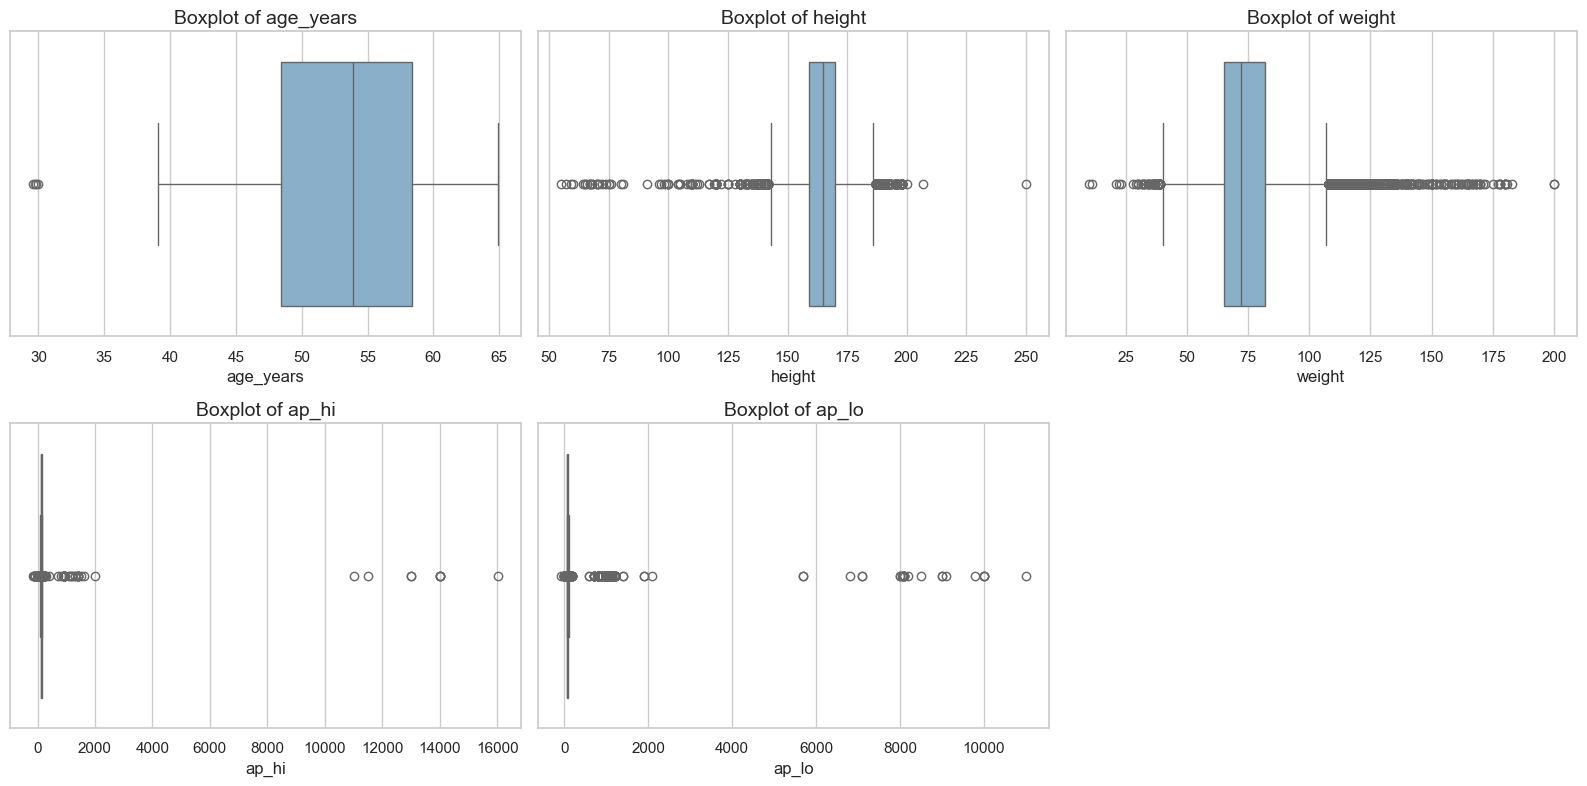

Insight: Blood pressure columns contain extreme values, so medical rules are needed before modeling.


In [9]:
# Convert age from days to years for understandable plotting.
df_outlier = df_clean.copy()
df_outlier["age_years"] = (df_outlier["age"] / 365.25).round(1)

outlier_columns = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

# Boxplots for visual outlier detection.
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for index, column in enumerate(outlier_columns):
    sns.boxplot(data=df_outlier, x=column, ax=axes[index], color="#80b1d3")
    axes[index].set_title(f"Boxplot of {column}")
    axes[index].set_xlabel(column)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

print("Insight: Blood pressure columns contain extreme values, so medical rules are needed before modeling.")


In [10]:
# IQR method for statistical outlier detection.
def calculate_iqr_outliers(data, columns):
    rows = []
    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outlier_count = ((data[column] < lower_bound) | (data[column] > upper_bound)).sum()
        rows.append({
            "Column": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "Outlier Count": outlier_count,
        })
    return pd.DataFrame(rows)

# Z-score method for statistical outlier detection.
def calculate_zscore_outliers(data, columns, threshold=3):
    rows = []
    for column in columns:
        mean_value = data[column].mean()
        std_value = data[column].std()
        z_scores = (data[column] - mean_value) / std_value
        outlier_count = (np.abs(z_scores) > threshold).sum()
        rows.append({
            "Column": column,
            "Mean": mean_value,
            "Standard Deviation": std_value,
            "Z-score Threshold": threshold,
            "Outlier Count": outlier_count,
        })
    return pd.DataFrame(rows)

display(Markdown("### IQR Outlier Table"))
display(calculate_iqr_outliers(df_outlier, outlier_columns))

display(Markdown("### Z-score Outlier Table"))
display(calculate_zscore_outliers(df_outlier, outlier_columns))

print("Insight: IQR and Z-score warn us about unusual values, but final removal should use medical judgment.")


### IQR Outlier Table

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,age_years,48.400,58.400,10.000,33.400,73.400,4
1,height,159.000,170.000,11.000,142.500,186.500,519
2,weight,65.000,82.000,17.000,39.500,107.500,1819
3,ap_hi,120.000,140.000,20.000,90.000,170.000,1435
4,ap_lo,80.000,90.000,10.000,65.000,105.000,4632


### Z-score Outlier Table

,Column,Mean,Standard Deviation,Z-score Threshold,Outlier Count
0,age_years,53.303,6.755,3,4
1,height,164.359,8.211,3,293
2,weight,74.209,14.397,3,702
3,ap_hi,128.820,154.038,3,38
4,ap_lo,96.636,188.505,3,951


Insight: IQR and Z-score warn us about unusual values, but final removal should use medical judgment.


In [11]:
# Add initial engineered features needed for cleaning.
df_clean["age_years"] = (df_clean["age"] / 365.25).round(1)
df_clean["bmi"] = df_clean["weight"] / ((df_clean["height"] / 100) ** 2)

cleaning_log = []

# Helper function to filter data and record how many rows were removed.
def apply_cleaning_rule(data, rule_name, condition_function):
    before_rows = len(data)
    condition = condition_function(data)
    cleaned_data = data.loc[condition].copy()
    after_rows = len(cleaned_data)
    cleaning_log.append({
        "Cleaning Rule": rule_name,
        "Rows Before": before_rows,
        "Rows Removed": before_rows - after_rows,
        "Rows After": after_rows,
    })
    return cleaned_data

# Apply broad medical plausibility rules.
df_cleaned = df_clean.copy()
df_cleaned = apply_cleaning_rule(df_cleaned, "Age between 25 and 80 years", lambda data: data["age_years"].between(25, 80))
df_cleaned = apply_cleaning_rule(df_cleaned, "Height between 120 and 220 cm", lambda data: data["height"].between(120, 220))
df_cleaned = apply_cleaning_rule(df_cleaned, "Weight between 30 and 200 kg", lambda data: data["weight"].between(30, 200))
df_cleaned = apply_cleaning_rule(df_cleaned, "Systolic BP ap_hi between 80 and 250", lambda data: data["ap_hi"].between(80, 250))
df_cleaned = apply_cleaning_rule(df_cleaned, "Diastolic BP ap_lo between 40 and 150", lambda data: data["ap_lo"].between(40, 150))
df_cleaned = apply_cleaning_rule(df_cleaned, "Systolic BP greater than diastolic BP", lambda data: data["ap_hi"] > data["ap_lo"])
df_cleaned = apply_cleaning_rule(df_cleaned, "BMI between 12 and 60", lambda data: data["bmi"].between(12, 60))

# Recalculate engineered medical features after cleaning.
df_cleaned["bmi"] = df_cleaned["weight"] / ((df_cleaned["height"] / 100) ** 2)
df_cleaned["pulse_pressure"] = df_cleaned["ap_hi"] - df_cleaned["ap_lo"]
df_cleaned["mean_arterial_pressure"] = (df_cleaned["ap_hi"] + 2 * df_cleaned["ap_lo"]) / 3

# Display cleaning summary.
display(pd.DataFrame(cleaning_log))
print(f"Original rows: {df_raw.shape[0]}")
print(f"Rows after cleaning: {df_cleaned.shape[0]}")
print(f"Total rows removed: {df_raw.shape[0] - df_cleaned.shape[0]}")
print("Insight: We remove medically unrealistic values but keep realistic high-risk values because they may be important.")


,Cleaning Rule,Rows Before,Rows Removed,Rows After
0,Age between 25 and 80 years,69976,0,69976
1,Height between 120 and 220 cm,69976,53,69923
2,Weight between 30 and 200 kg,69923,7,69916
3,Systolic BP ap_hi between 80 and 250,69916,245,69671
4,Diastolic BP ap_lo between 40 and 150,69671,1013,68658
5,Systolic BP greater than diastolic BP,68658,76,68582
6,BMI between 12 and 60,68582,25,68557


Original rows: 70000
Rows after cleaning: 68557
Total rows removed: 1443
Insight: We remove medically unrealistic values but keep realistic high-risk values because they may be important.


In [12]:
# Review cleaned numeric summary.
display(df_cleaned[[
    "age_years", "height", "weight", "ap_hi", "ap_lo", "bmi", "pulse_pressure", "mean_arterial_pressure"
]].describe().T)


,count,mean,std,min,25%,50%,75%,max
age_years,68557.000,53.292,6.757,29.600,48.300,53.900,58.400,64.900
height,68557.000,164.418,7.906,120.000,159.000,165.000,170.000,207.000
weight,68557.000,74.093,14.213,30.000,65.000,72.000,82.000,200.000
ap_hi,68557.000,126.673,16.672,80.000,120.000,120.000,140.000,240.000
ap_lo,68557.000,81.303,9.419,40.000,80.000,80.000,90.000,150.000
bmi,68557.000,27.446,5.199,12.254,23.875,26.346,30.116,59.524
pulse_pressure,68557.000,45.370,11.662,5.000,40.000,40.000,50.000,140.000
mean_arterial_pressure,68557.000,96.427,11.026,53.333,93.333,93.333,103.333,173.333


# 5. Feature Engineering

Feature engineering creates better input variables for the model.

We create `age_years`, `bmi`, `pulse_pressure`, `mean_arterial_pressure`, `bp_category`, and `bmi_category`.


In [13]:
# Maps for readable labels.
gender_map = {1: "Female", 2: "Male"}
cholesterol_map = {1: "Normal", 2: "Above Normal", 3: "Well Above Normal"}
glucose_map = {1: "Normal", 2: "Above Normal", 3: "Well Above Normal"}
binary_map = {0: "No", 1: "Yes"}
active_map = {0: "Not Active", 1: "Active"}
target_map = {0: "No Disease", 1: "Disease"}

# Function to create blood pressure categories.
def classify_blood_pressure(row):
    systolic = row["ap_hi"]
    diastolic = row["ap_lo"]
    if systolic >= 140 or diastolic >= 90:
        return "Hypertension Stage 2"
    elif systolic >= 130 or diastolic >= 80:
        return "Hypertension Stage 1"
    elif systolic >= 120 and diastolic < 80:
        return "Elevated"
    else:
        return "Normal"

# Add categorical engineered features.
df_cleaned["bp_category"] = df_cleaned.apply(classify_blood_pressure, axis=1)
df_cleaned["bmi_category"] = pd.cut(
    df_cleaned["bmi"],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=["Underweight", "Normal", "Overweight", "Obesity"]
).astype(str)

# Create a labeled copy for clearer EDA graphs.
df_eda = df_cleaned.copy()
df_eda["gender_label"] = df_eda["gender"].map(gender_map)
df_eda["cholesterol_label"] = df_eda["cholesterol"].map(cholesterol_map)
df_eda["glucose_label"] = df_eda["gluc"].map(glucose_map)
df_eda["smoke_label"] = df_eda["smoke"].map(binary_map)
df_eda["alcohol_label"] = df_eda["alco"].map(binary_map)
df_eda["active_label"] = df_eda["active"].map(active_map)
df_eda["cardio_label"] = df_eda["cardio"].map(target_map)

display(df_eda[[
    "age_years", "height", "weight", "bmi", "bmi_category", "ap_hi", "ap_lo",
    "pulse_pressure", "mean_arterial_pressure", "bp_category", "cardio_label"
]].head())


,age_years,height,weight,bmi,bmi_category,ap_hi,ap_lo,pulse_pressure,mean_arterial_pressure,bp_category,cardio_label
0,50.400,168,62.000,21.967,Normal,110,80,30,90.000,Hypertension Stage 1,No Disease
1,55.400,156,85.000,34.928,Obesity,140,90,50,106.667,Hypertension Stage 2,Disease
2,51.600,165,64.000,23.508,Normal,130,70,60,90.000,Hypertension Stage 1,Disease
3,48.200,169,82.000,28.710,Overweight,150,100,50,116.667,Hypertension Stage 2,Disease
4,47.800,156,56.000,23.011,Normal,100,60,40,73.333,Normal,No Disease


# 6. Exploratory Data Analysis (EDA)

EDA helps us understand patterns before modeling. Every chart below includes titles, labels, and a short insight.


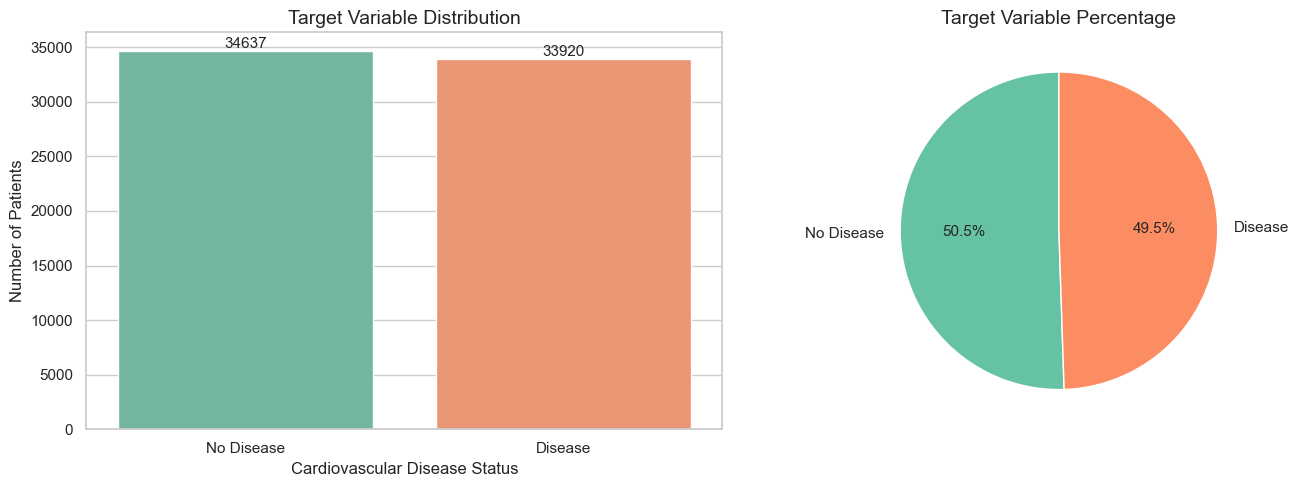

Insight: Disease rate is 49.48%, so the target is almost balanced.


In [14]:
# Target variable distribution with count plot and pie chart.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_eda, x="cardio_label", ax=axes[0], palette="Set2")
axes[0].set_title("Target Variable Distribution")
axes[0].set_xlabel("Cardiovascular Disease Status")
axes[0].set_ylabel("Number of Patients")
for container in axes[0].containers:
    axes[0].bar_label(container)

target_counts = df_eda["cardio_label"].value_counts()
axes[1].pie(target_counts.values, labels=target_counts.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Set2", 2))
axes[1].set_title("Target Variable Percentage")
plt.tight_layout()
plt.show()

print(f"Insight: Disease rate is {df_eda['cardio'].mean() * 100:.2f}%, so the target is almost balanced.")


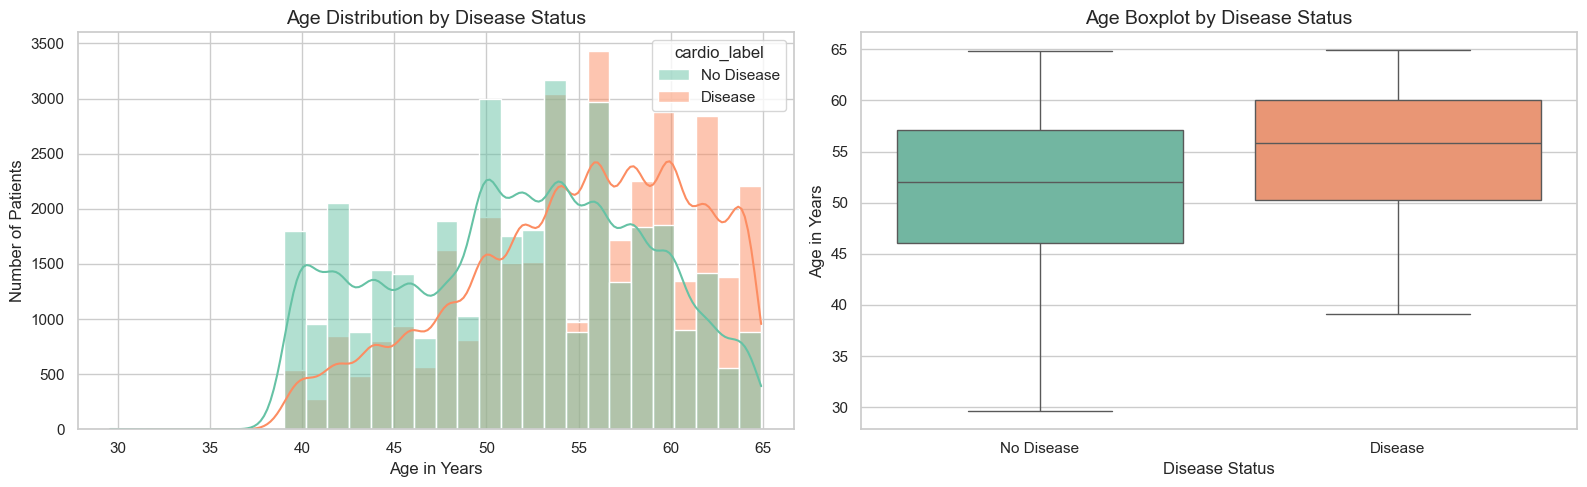

,Median Age
cardio_label,
Disease,55.800
No Disease,52.000


Insight: Patients with disease usually have a higher median age.


In [15]:
# Age distribution and boxplot by disease status.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=df_eda, x="age_years", hue="cardio_label", kde=True, bins=30, ax=axes[0], palette="Set2")
axes[0].set_title("Age Distribution by Disease Status")
axes[0].set_xlabel("Age in Years")
axes[0].set_ylabel("Number of Patients")

sns.boxplot(data=df_eda, x="cardio_label", y="age_years", ax=axes[1], palette="Set2")
axes[1].set_title("Age Boxplot by Disease Status")
axes[1].set_xlabel("Disease Status")
axes[1].set_ylabel("Age in Years")
plt.tight_layout()
plt.show()

age_medians = df_eda.groupby("cardio_label")["age_years"].median()
display(age_medians.to_frame(name="Median Age"))
print("Insight: Patients with disease usually have a higher median age.")


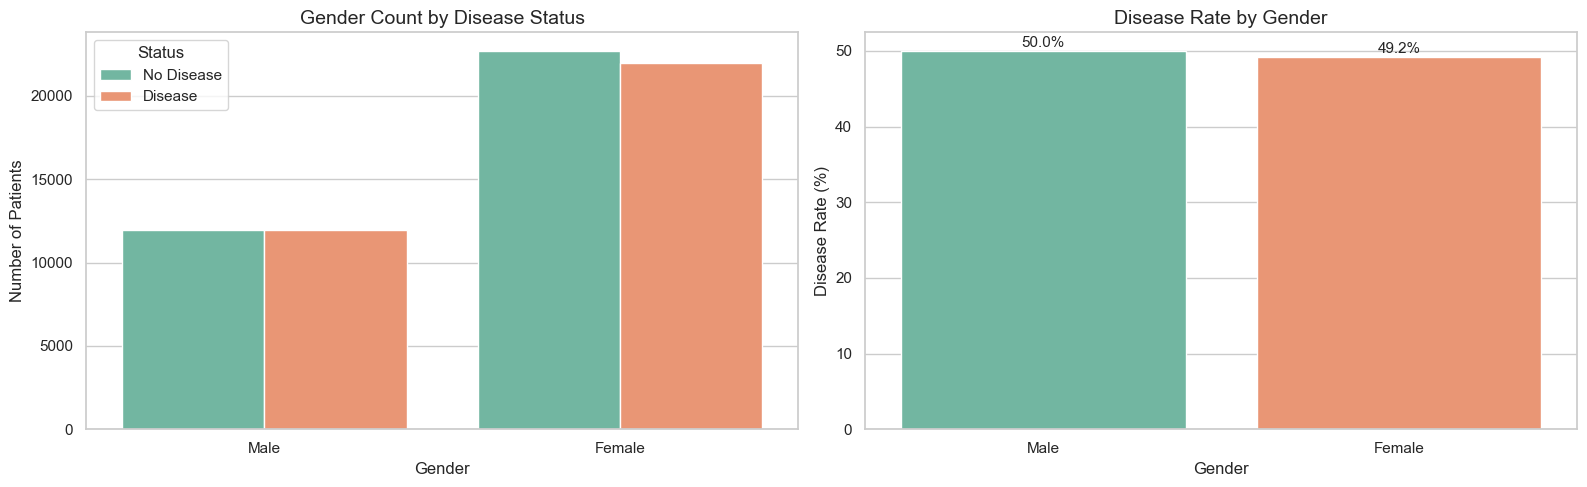

,Disease Rate (%)
gender_label,
Male,49.969
Female,49.214


Insight: This checks whether the disease rate differs between gender groups.


In [16]:
# Gender analysis.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.countplot(data=df_eda, x="gender_label", hue="cardio_label", ax=axes[0], palette="Set2")
axes[0].set_title("Gender Count by Disease Status")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Number of Patients")
axes[0].legend(title="Status")

gender_rate = df_eda.groupby("gender_label")["cardio"].mean().sort_values(ascending=False) * 100
sns.barplot(x=gender_rate.index, y=gender_rate.values, ax=axes[1], palette="Set2")
axes[1].set_title("Disease Rate by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Disease Rate (%)")
for index, value in enumerate(gender_rate.values):
    axes[1].text(index, value + 0.5, f"{value:.1f}%", ha="center")
plt.tight_layout()
plt.show()

display(gender_rate.to_frame(name="Disease Rate (%)"))
print("Insight: This checks whether the disease rate differs between gender groups.")


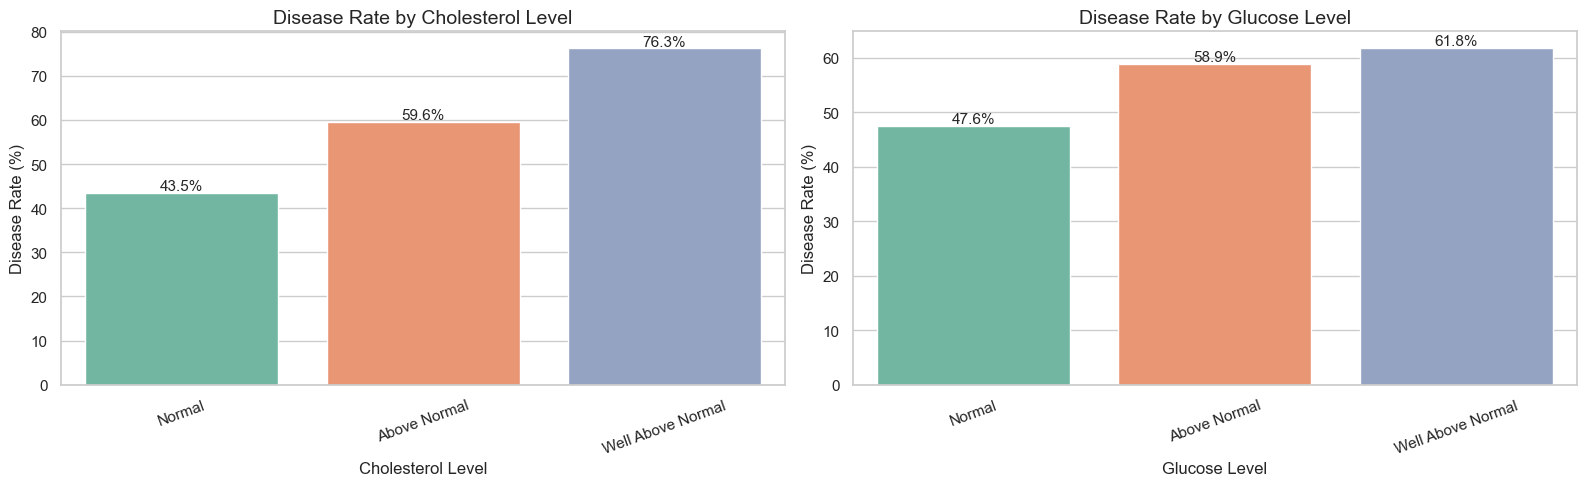

Insight: Higher cholesterol and glucose levels can be compared with higher disease rates.


In [17]:
# Cholesterol and glucose disease rates.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

chol_order = ["Normal", "Above Normal", "Well Above Normal"]
chol_rate = df_eda.groupby("cholesterol_label")["cardio"].mean().reindex(chol_order) * 100
sns.barplot(x=chol_rate.index, y=chol_rate.values, ax=axes[0], palette="Set2")
axes[0].set_title("Disease Rate by Cholesterol Level")
axes[0].set_xlabel("Cholesterol Level")
axes[0].set_ylabel("Disease Rate (%)")
axes[0].tick_params(axis="x", rotation=20)
for index, value in enumerate(chol_rate.values):
    axes[0].text(index, value + 0.5, f"{value:.1f}%", ha="center")

gluc_rate = df_eda.groupby("glucose_label")["cardio"].mean().reindex(chol_order) * 100
sns.barplot(x=gluc_rate.index, y=gluc_rate.values, ax=axes[1], palette="Set2")
axes[1].set_title("Disease Rate by Glucose Level")
axes[1].set_xlabel("Glucose Level")
axes[1].set_ylabel("Disease Rate (%)")
axes[1].tick_params(axis="x", rotation=20)
for index, value in enumerate(gluc_rate.values):
    axes[1].text(index, value + 0.5, f"{value:.1f}%", ha="center")
plt.tight_layout()
plt.show()

print("Insight: Higher cholesterol and glucose levels can be compared with higher disease rates.")


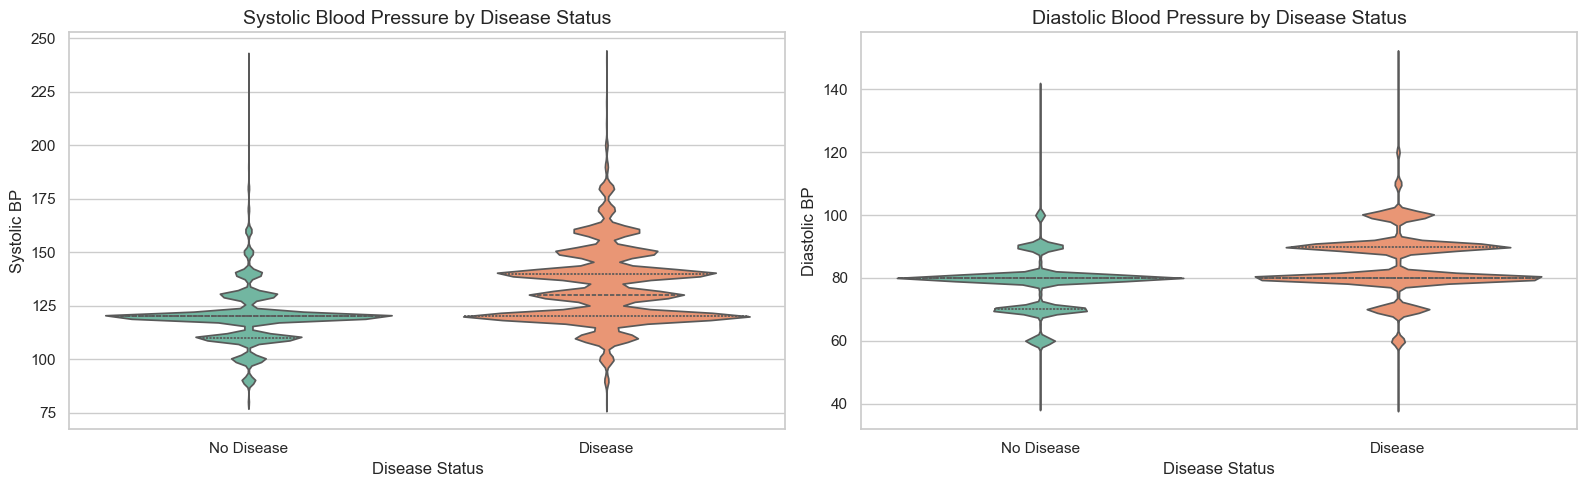

,ap_hi,ap_lo
cardio_label,,
Disease,130.000,80.000
No Disease,120.000,80.000


Insight: Higher blood pressure is usually associated with higher cardiovascular disease risk.


In [18]:
# Blood pressure violin plots.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.violinplot(data=df_eda, x="cardio_label", y="ap_hi", ax=axes[0], palette="Set2", inner="quartile")
axes[0].set_title("Systolic Blood Pressure by Disease Status")
axes[0].set_xlabel("Disease Status")
axes[0].set_ylabel("Systolic BP")

sns.violinplot(data=df_eda, x="cardio_label", y="ap_lo", ax=axes[1], palette="Set2", inner="quartile")
axes[1].set_title("Diastolic Blood Pressure by Disease Status")
axes[1].set_xlabel("Disease Status")
axes[1].set_ylabel("Diastolic BP")
plt.tight_layout()
plt.show()

bp_medians = df_eda.groupby("cardio_label")[["ap_hi", "ap_lo"]].median()
display(bp_medians)
print("Insight: Higher blood pressure is usually associated with higher cardiovascular disease risk.")


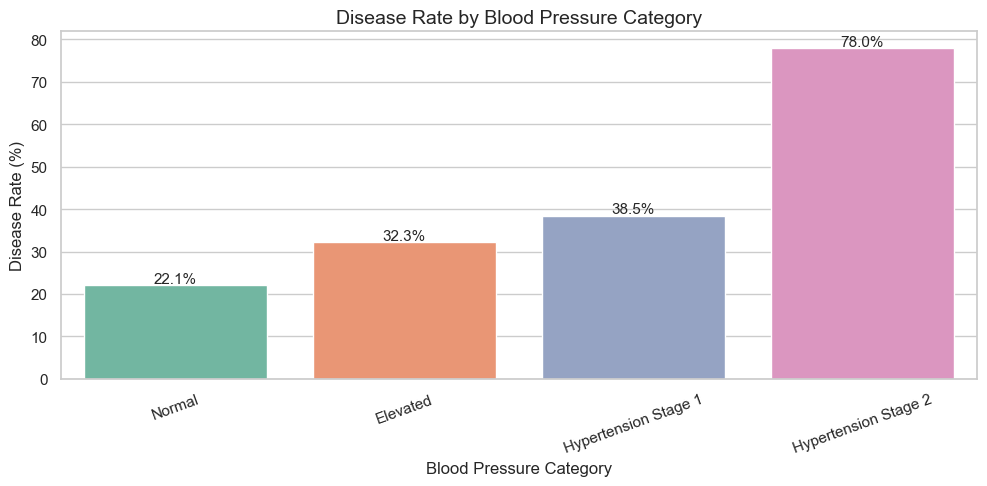

,Disease Rate (%)
bp_category,
Normal,22.135
Elevated,32.325
Hypertension Stage 1,38.472
Hypertension Stage 2,78.004


Insight: This graph shows whether disease rate rises as blood pressure category becomes more severe.


In [19]:
# Disease rate by blood pressure category.
bp_order = ["Normal", "Elevated", "Hypertension Stage 1", "Hypertension Stage 2"]
bp_rate = df_eda.groupby("bp_category")["cardio"].mean().reindex(bp_order) * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=bp_rate.index, y=bp_rate.values, palette="Set2")
plt.title("Disease Rate by Blood Pressure Category")
plt.xlabel("Blood Pressure Category")
plt.ylabel("Disease Rate (%)")
plt.xticks(rotation=20)
for index, value in enumerate(bp_rate.values):
    if pd.notna(value):
        plt.text(index, value + 0.5, f"{value:.1f}%", ha="center")
plt.tight_layout()
plt.show()

display(bp_rate.to_frame(name="Disease Rate (%)"))
print("Insight: This graph shows whether disease rate rises as blood pressure category becomes more severe.")


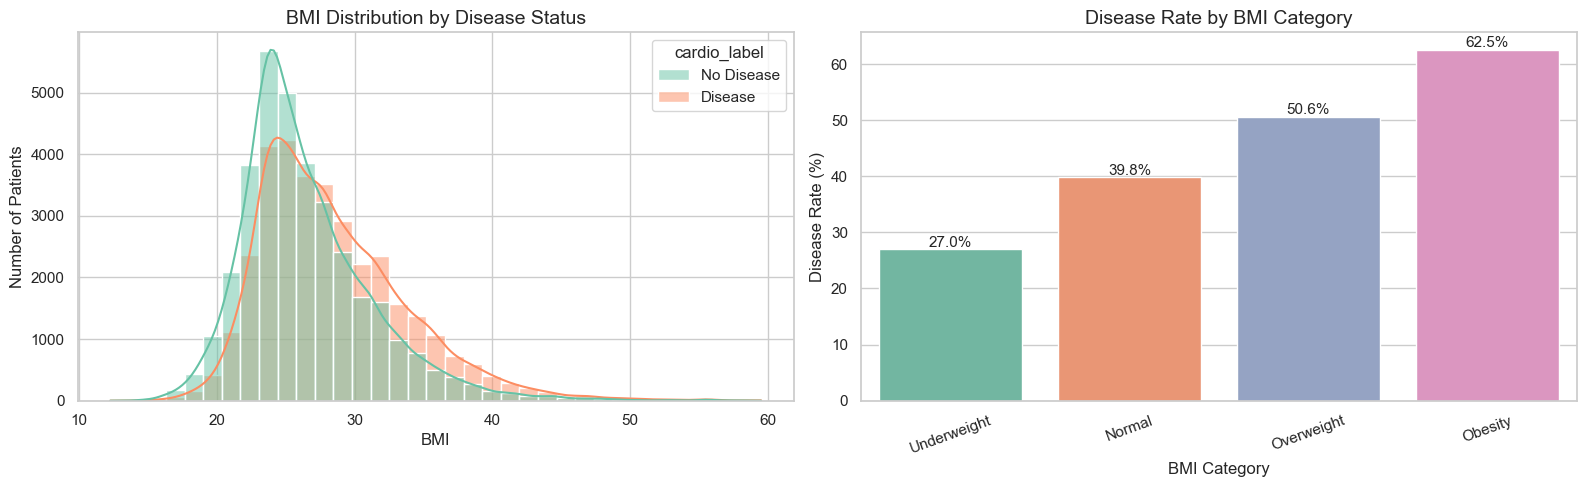

Insight: BMI helps show whether overweight or obesity groups have higher disease rates.


In [20]:
# BMI distribution and BMI category disease rate.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(data=df_eda, x="bmi", hue="cardio_label", kde=True, bins=35, ax=axes[0], palette="Set2")
axes[0].set_title("BMI Distribution by Disease Status")
axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Number of Patients")

bmi_order = ["Underweight", "Normal", "Overweight", "Obesity"]
bmi_rate = df_eda.groupby("bmi_category")["cardio"].mean().reindex(bmi_order) * 100
sns.barplot(x=bmi_rate.index, y=bmi_rate.values, ax=axes[1], palette="Set2")
axes[1].set_title("Disease Rate by BMI Category")
axes[1].set_xlabel("BMI Category")
axes[1].set_ylabel("Disease Rate (%)")
axes[1].tick_params(axis="x", rotation=20)
for index, value in enumerate(bmi_rate.values):
    if pd.notna(value):
        axes[1].text(index, value + 0.5, f"{value:.1f}%", ha="center")
plt.tight_layout()
plt.show()

print("Insight: BMI helps show whether overweight or obesity groups have higher disease rates.")


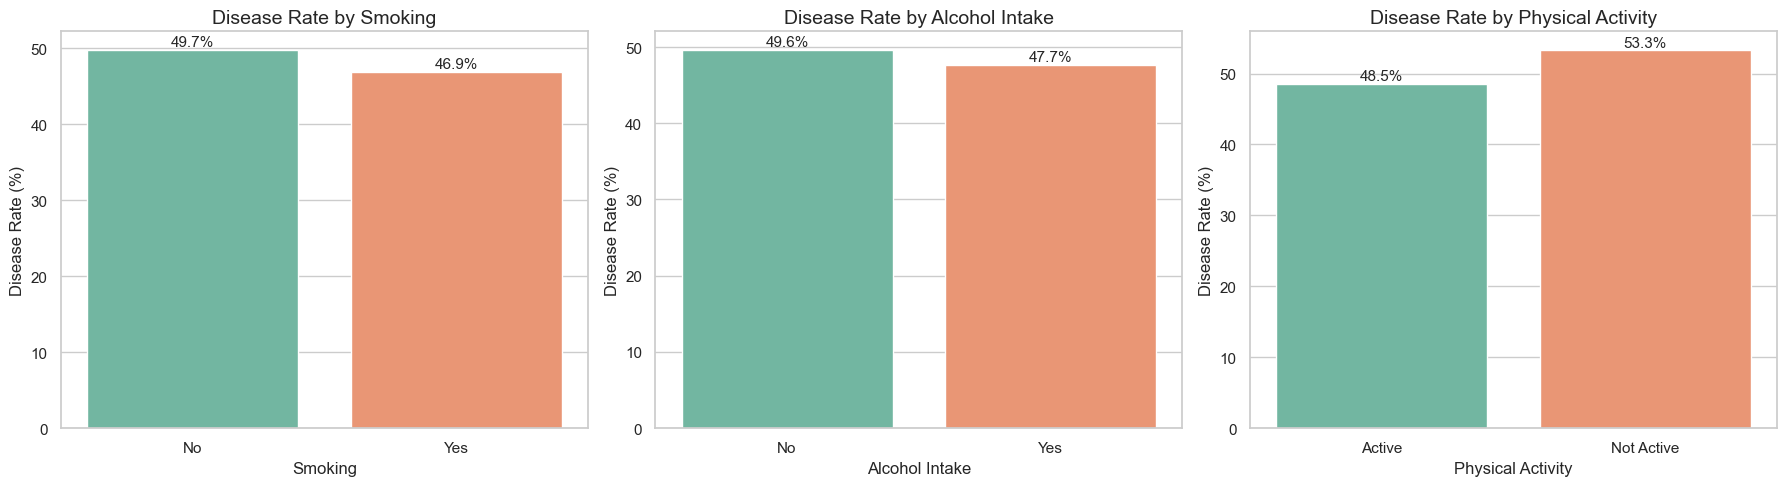

Insight: Lifestyle variables may look weak alone, but they can still help when combined with other features.


In [21]:
# Lifestyle features: smoking, alcohol, and physical activity.
lifestyle_columns = {
    "smoke_label": "Smoking",
    "alcohol_label": "Alcohol Intake",
    "active_label": "Physical Activity",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for axis, (column, title) in zip(axes, lifestyle_columns.items()):
    lifestyle_rate = df_eda.groupby(column)["cardio"].mean() * 100
    sns.barplot(x=lifestyle_rate.index, y=lifestyle_rate.values, ax=axis, palette="Set2")
    axis.set_title(f"Disease Rate by {title}")
    axis.set_xlabel(title)
    axis.set_ylabel("Disease Rate (%)")
    for index, value in enumerate(lifestyle_rate.values):
        axis.text(index, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

print("Insight: Lifestyle variables may look weak alone, but they can still help when combined with other features.")


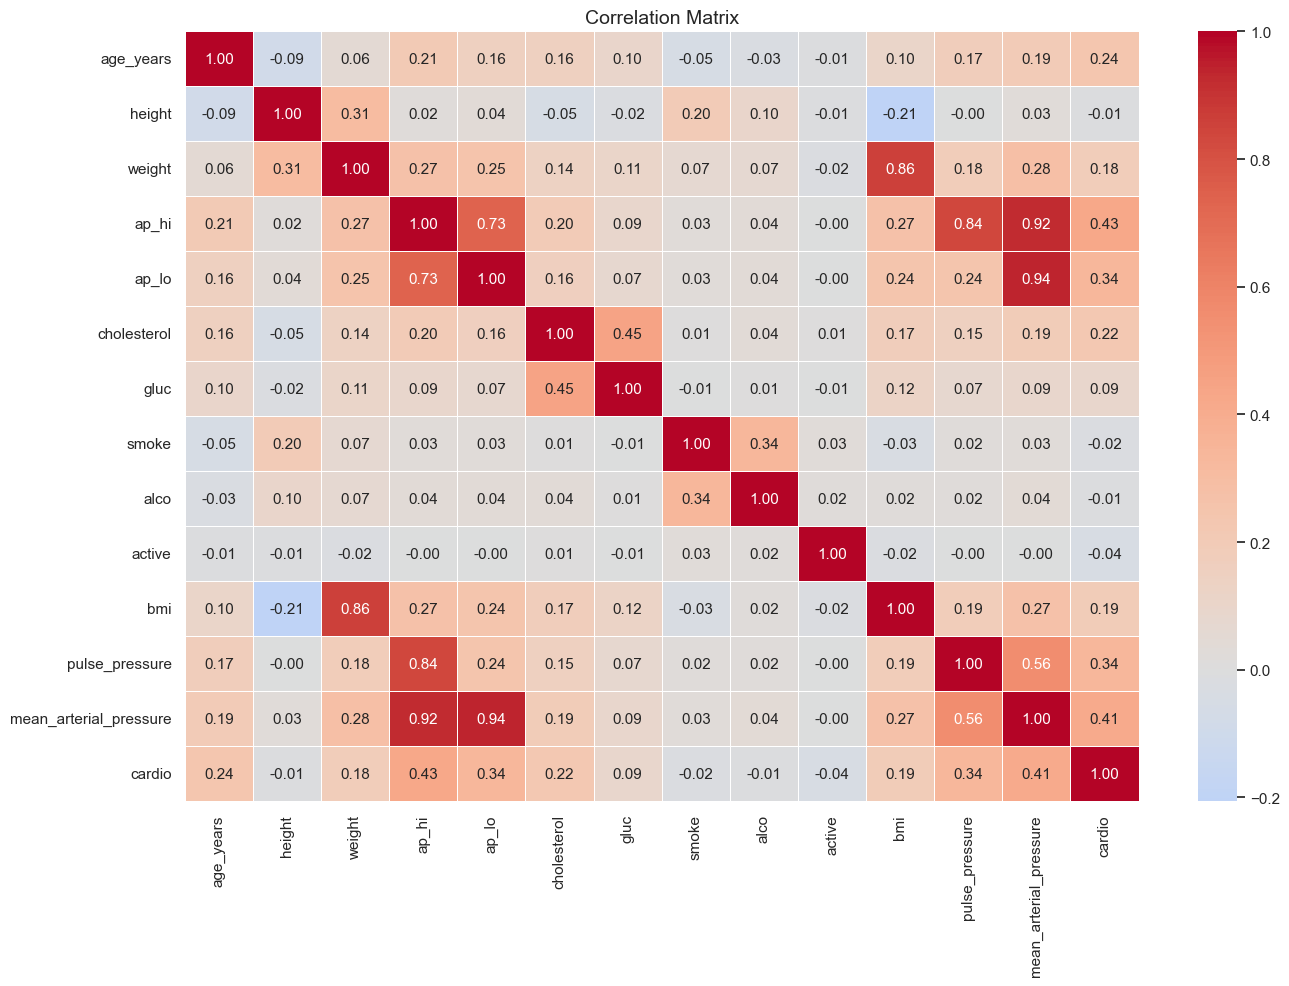

,Correlation With Cardio
ap_hi,0.428
mean_arterial_pressure,0.410
ap_lo,0.341
pulse_pressure,0.337
age_years,0.240
cholesterol,0.221
bmi,0.191
weight,0.181


Insight: Correlation helps identify variables most linearly related to the target.


In [22]:
# Correlation heatmap.
correlation_columns = [
    "age_years", "height", "weight", "ap_hi", "ap_lo", "cholesterol", "gluc",
    "smoke", "alco", "active", "bmi", "pulse_pressure", "mean_arterial_pressure", "cardio"
]

corr_matrix = df_cleaned[correlation_columns].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

target_corr = corr_matrix["cardio"].drop("cardio").sort_values(key=lambda values: values.abs(), ascending=False)
display(target_corr.head(8).to_frame(name="Correlation With Cardio"))
print("Insight: Correlation helps identify variables most linearly related to the target.")


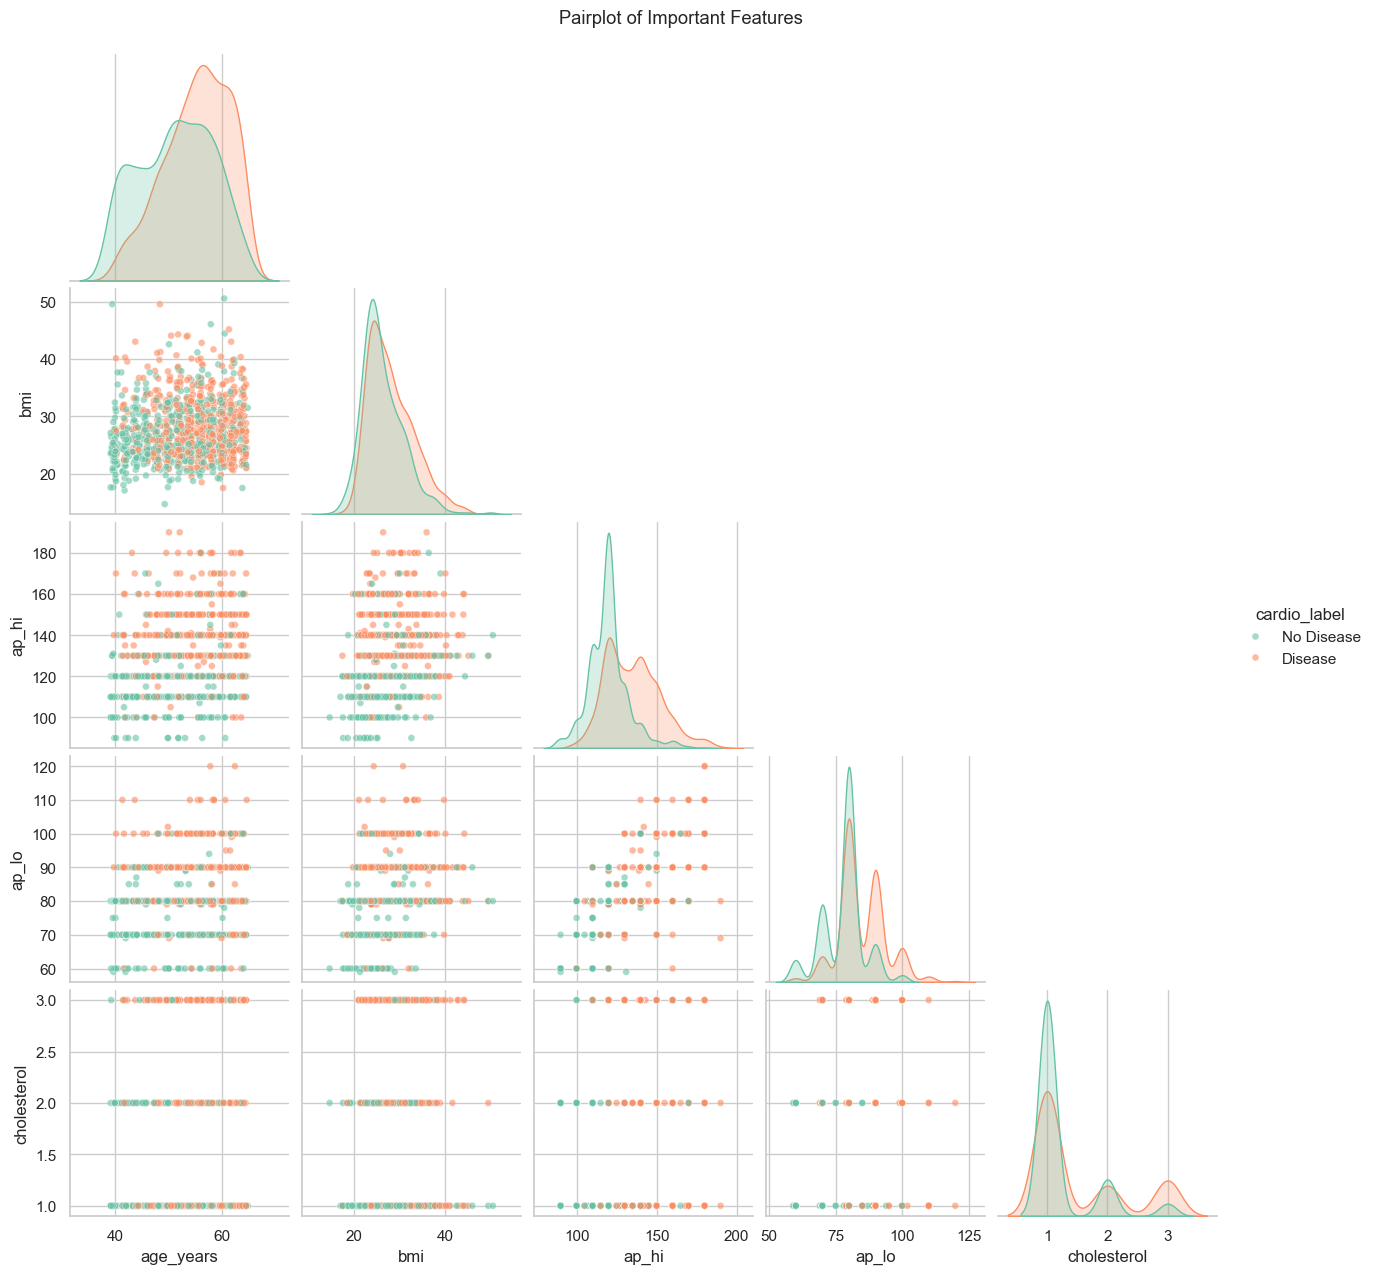

Insight: Medical data rarely separates perfectly, so models learn from combined patterns across features.


In [23]:
# Pairplot on a sample because pairplots are slow on large datasets.
pairplot_sample = df_eda.sample(n=min(1200, len(df_eda)), random_state=RANDOM_STATE)
pairplot_columns = ["age_years", "bmi", "ap_hi", "ap_lo", "cholesterol", "cardio_label"]

sns.pairplot(
    pairplot_sample[pairplot_columns],
    hue="cardio_label",
    diag_kind="kde",
    corner=True,
    palette="Set2",
    plot_kws={"alpha": 0.6, "s": 25},
)
plt.suptitle("Pairplot of Important Features", y=1.02)
plt.show()

print("Insight: Medical data rarely separates perfectly, so models learn from combined patterns across features.")


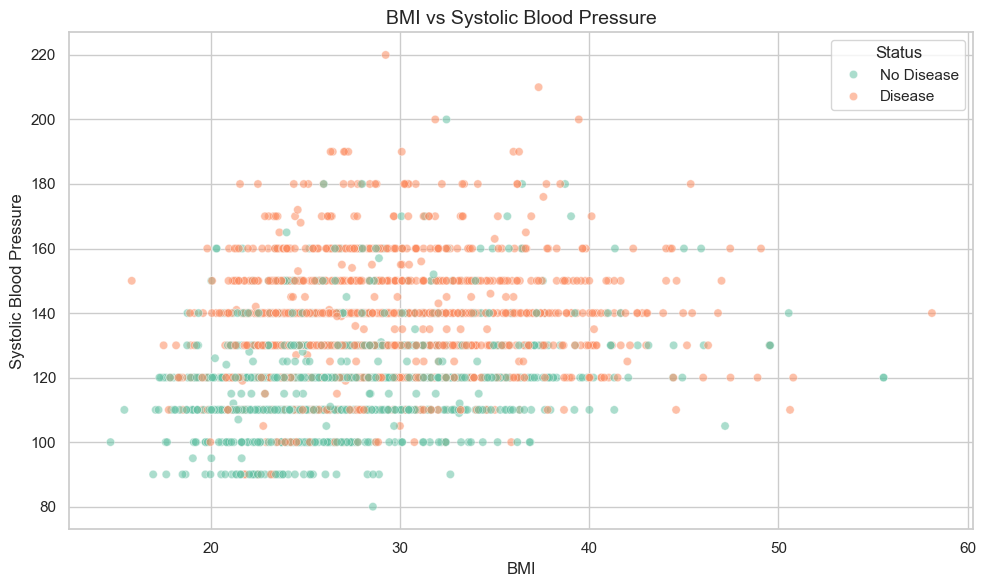

Insight: This checks whether high BMI and high blood pressure appear together in disease cases.


In [24]:
# Scatter plot: BMI vs systolic blood pressure.
scatter_sample = df_eda.sample(n=min(3500, len(df_eda)), random_state=RANDOM_STATE)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_sample, x="bmi", y="ap_hi", hue="cardio_label", alpha=0.55, palette="Set2")
plt.title("BMI vs Systolic Blood Pressure")
plt.xlabel("BMI")
plt.ylabel("Systolic Blood Pressure")
plt.legend(title="Status")
plt.tight_layout()
plt.show()

print("Insight: This checks whether high BMI and high blood pressure appear together in disease cases.")


# 7. Prepare Data for Machine Learning

We prepare the feature matrix `X` and target vector `y`.

Important choices:

- Remove `id` because it is just an identifier.
- Remove raw `age` because `age_years` is easier to understand.
- Use OneHotEncoding for categorical variables.
- Use StandardScaler for numeric variables.
- Demonstrate MinMaxScaler and LabelEncoder for learning.


In [25]:
# Create modeling data from cleaned data.
model_data = df_cleaned.copy()

# Convert categorical codes to readable labels before encoding.
model_data["gender"] = model_data["gender"].map(gender_map)
model_data["cholesterol"] = model_data["cholesterol"].map(cholesterol_map)
model_data["gluc"] = model_data["gluc"].map(glucose_map)
model_data["smoke"] = model_data["smoke"].map(binary_map)
model_data["alco"] = model_data["alco"].map(binary_map)
model_data["active"] = model_data["active"].map(active_map)

# Numeric features.
numeric_features = [
    "age_years", "height", "weight", "ap_hi", "ap_lo", "bmi",
    "pulse_pressure", "mean_arterial_pressure",
]

# Categorical features.
categorical_features = [
    "gender", "cholesterol", "gluc", "smoke", "alco", "active", "bp_category", "bmi_category",
]

# Final feature columns.
feature_columns = numeric_features + categorical_features

X = model_data[feature_columns]
y = model_data["cardio"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("Features used for modeling:")
print(feature_columns)


X shape: (68557, 16)
y shape: (68557,)
Features used for modeling:
['age_years', 'height', 'weight', 'ap_hi', 'ap_lo', 'bmi', 'pulse_pressure', 'mean_arterial_pressure', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bp_category', 'bmi_category']


In [26]:
# LabelEncoder demonstration.
# The target is already numeric, but this shows how encoding works for classification labels.
label_encoder = LabelEncoder()
y_encoded = pd.Series(label_encoder.fit_transform(y), index=y.index, name="cardio_encoded")

print("Original target values:", sorted(y.unique()))
print("Encoded target values:", sorted(y_encoded.unique()))
print("LabelEncoder classes:", label_encoder.classes_)


Original target values: [np.int64(0), np.int64(1)]
Encoded target values: [np.int64(0), np.int64(1)]
LabelEncoder classes: [0 1]


In [27]:
# MinMaxScaler demonstration.
# MinMaxScaler changes numeric values to a 0 to 1 range.
minmax_scaler = MinMaxScaler()
minmax_preview = pd.DataFrame(
    minmax_scaler.fit_transform(model_data[numeric_features]),
    columns=[f"{column}_minmax" for column in numeric_features],
    index=model_data.index,
)

display(Markdown("### MinMaxScaler Preview"))
display(minmax_preview.head())

print("Insight: MinMaxScaler is useful for distance-based models. Our final pipeline uses StandardScaler for Logistic Regression.")


### MinMaxScaler Preview

,age_years_minmax,height_minmax,weight_minmax,ap_hi_minmax,ap_lo_minmax,bmi_minmax,pulse_pressure_minmax,mean_arterial_pressure_minmax
0,0.589,0.552,0.188,0.188,0.364,0.205,0.185,0.306
1,0.731,0.414,0.324,0.375,0.455,0.480,0.333,0.444
2,0.623,0.517,0.200,0.312,0.273,0.238,0.407,0.306
3,0.527,0.563,0.306,0.438,0.545,0.348,0.333,0.528
4,0.516,0.414,0.153,0.125,0.182,0.228,0.259,0.167


Insight: MinMaxScaler is useful for distance-based models. Our final pipeline uses StandardScaler for Logistic Regression.


In [28]:
# Preprocessing for numeric columns.
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Preprocessing for categorical columns.
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

# Apply the correct preprocessing to each column group.
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

print("Preprocessing pipeline is ready.")


Preprocessing pipeline is ready.


# 8. Train-Test Split

We split the dataset into training and testing sets. Training data teaches the model, and testing data checks performance on unseen records. We use `stratify=y` to keep the disease/no-disease ratio similar in both sets.


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_encoded,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

train_distribution = y_train.value_counts(normalize=True).rename("Train %") * 100
test_distribution = y_test.value_counts(normalize=True).rename("Test %") * 100
display(pd.concat([train_distribution, test_distribution], axis=1))


X_train shape: (54845, 16)
X_test shape: (13712, 16)
y_train shape: (54845,)
y_test shape: (13712,)


,Train %,Test %
cardio_encoded,,
0,50.522,50.525
1,49.478,49.475


# 9. Train Machine Learning Models

We train two models:

## Logistic Regression
A simple, fast, and explainable classification model.

## Random Forest
A strong model that combines many decision trees and often works well on tabular data.


In [30]:
# Create model pipelines.
models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=RANDOM_STATE,
            class_weight="balanced",
            n_jobs=-1,
        )),
    ]),
}

# Train the models.
trained_models = {}

for model_name, model_pipeline in models.items():
    print(f"Training {model_name}...")
    model_pipeline.fit(X_train, y_train)
    trained_models[model_name] = model_pipeline
    print(f"{model_name} training completed.")


Training Logistic Regression...
Logistic Regression training completed.
Training Random Forest...
Random Forest training completed.


# 10. Model Evaluation

For a healthcare-style classification project, we evaluate several metrics instead of only accuracy.


In [31]:
# Function to evaluate one classifier.
def evaluate_classifier(model_name, model, X_test_data, y_test_data):
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test_data, y_pred),
        "Precision": precision_score(y_test_data, y_pred, zero_division=0),
        "Recall": recall_score(y_test_data, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test_data, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test_data, y_proba),
    }
    return metrics, y_pred, y_proba

# Evaluate baseline models.
evaluation_results = []
prediction_outputs = {}

for model_name, model in trained_models.items():
    metrics, y_pred, y_proba = evaluate_classifier(model_name, model, X_test, y_test)
    evaluation_results.append(metrics)
    prediction_outputs[model_name] = {"y_pred": y_pred, "y_proba": y_proba}

evaluation_df = pd.DataFrame(evaluation_results).sort_values(by="ROC-AUC", ascending=False)
display(evaluation_df)

print("Insight: The best model should have strong ROC-AUC while keeping precision and recall balanced.")


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.732,0.764,0.663,0.710,0.798
1,Random Forest,0.709,0.709,0.697,0.703,0.770


Insight: The best model should have strong ROC-AUC while keeping precision and recall balanced.


In [32]:
# Classification reports.
for model_name, outputs in prediction_outputs.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)
    print(classification_report(y_test, outputs["y_pred"], target_names=["No Disease", "Disease"]))


Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.71      0.80      0.75      6928
     Disease       0.76      0.66      0.71      6784

    accuracy                           0.73     13712
   macro avg       0.74      0.73      0.73     13712
weighted avg       0.74      0.73      0.73     13712

Random Forest
              precision    recall  f1-score   support

  No Disease       0.71      0.72      0.71      6928
     Disease       0.71      0.70      0.70      6784

    accuracy                           0.71     13712
   macro avg       0.71      0.71      0.71     13712
weighted avg       0.71      0.71      0.71     13712



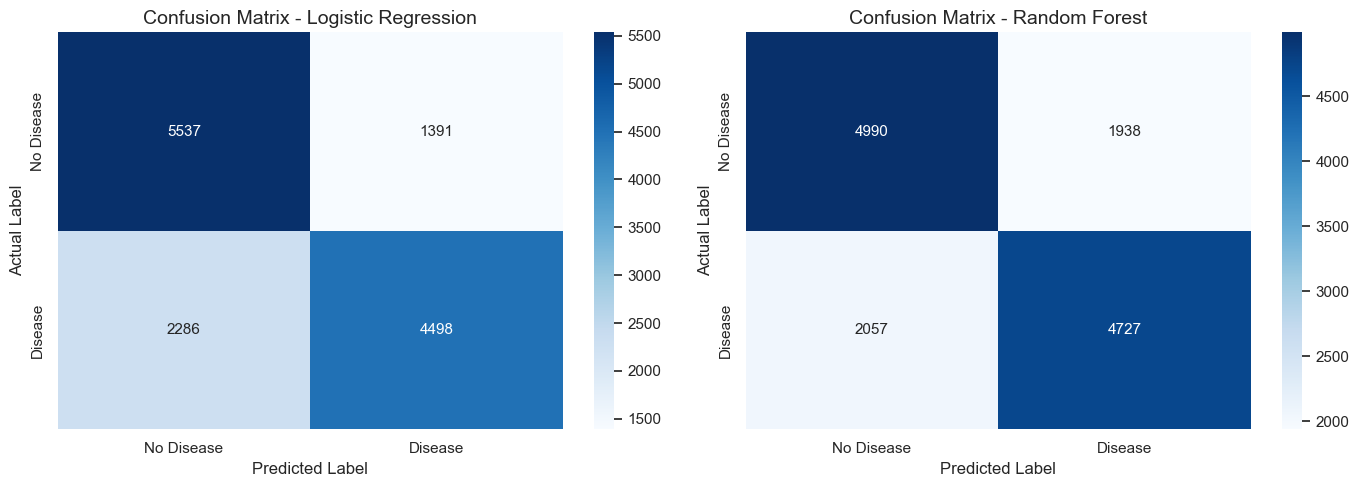

Insight: False negatives are important because they mean actual disease cases were missed.


In [33]:
# Confusion matrix heatmaps.
fig, axes = plt.subplots(1, len(trained_models), figsize=(7 * len(trained_models), 5))
if len(trained_models) == 1:
    axes = [axes]

for axis, (model_name, outputs) in zip(axes, prediction_outputs.items()):
    cm = confusion_matrix(y_test, outputs["y_pred"])
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"],
        ax=axis,
    )
    axis.set_title(f"Confusion Matrix - {model_name}")
    axis.set_xlabel("Predicted Label")
    axis.set_ylabel("Actual Label")

plt.tight_layout()
plt.show()

print("Insight: False negatives are important because they mean actual disease cases were missed.")


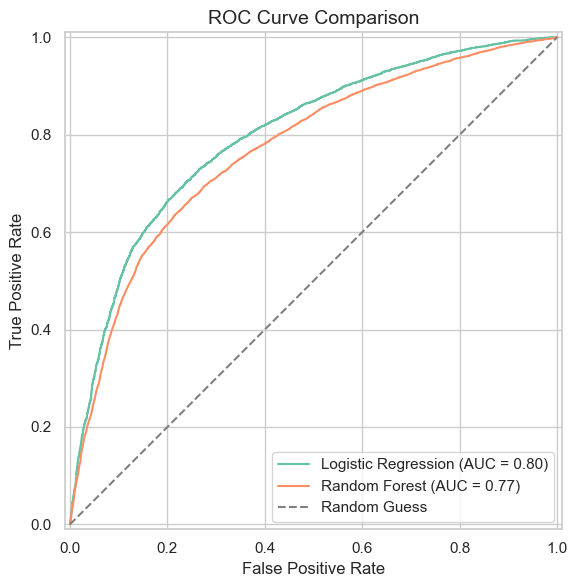

Insight: A ROC curve closer to the top-left corner is better.


In [34]:
# ROC curves.
plt.figure(figsize=(9, 6))
for model_name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=model_name, ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

print("Insight: A ROC curve closer to the top-left corner is better.")


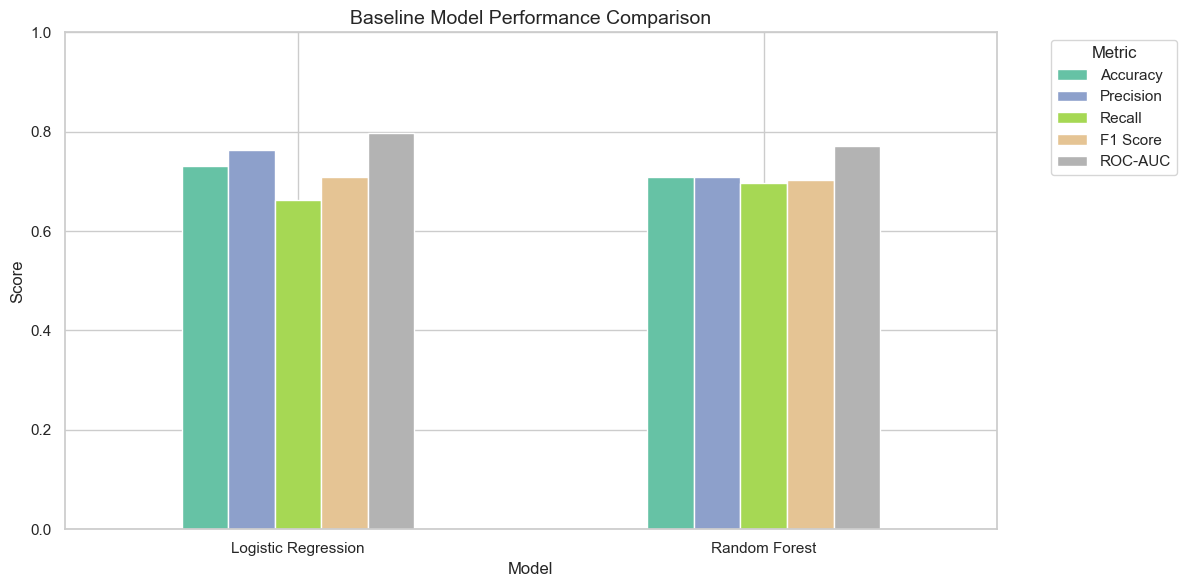

Insight: This table and graph compare both models side-by-side.


In [35]:
# Model comparison graph.
metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
comparison_plot_df = evaluation_df.set_index("Model")[metric_columns]

comparison_plot_df.plot(kind="bar", figsize=(12, 6), colormap="Set2")
plt.title("Baseline Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Insight: This table and graph compare both models side-by-side.")


# 11. Cross-Validation

Cross-validation gives a more stable estimate of model performance by training and validating the model on different splits of the training data.


In [36]:
# StratifiedKFold keeps the target balance similar in each fold.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

cv_rows = []

for model_name, model_pipeline in models.items():
    print(f"Running cross-validation for {model_name}...")
    cv_result = cross_validate(model_pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_rows.append({
        "Model": model_name,
        "CV Accuracy": cv_result["test_accuracy"].mean(),
        "CV Precision": cv_result["test_precision"].mean(),
        "CV Recall": cv_result["test_recall"].mean(),
        "CV F1": cv_result["test_f1"].mean(),
        "CV ROC-AUC": cv_result["test_roc_auc"].mean(),
    })

cv_results_df = pd.DataFrame(cv_rows).sort_values(by="CV ROC-AUC", ascending=False)
display(cv_results_df)

print("Insight: Cross-validation reduces the chance of trusting a lucky single train-test split.")


Running cross-validation for Logistic Regression...


Running cross-validation for Random Forest...


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.729,0.762,0.657,0.706,0.793
1,Random Forest,0.707,0.709,0.693,0.701,0.768


Insight: Cross-validation reduces the chance of trusting a lucky single train-test split.


# 12. Hyperparameter Tuning

We tune the Random Forest using `RandomizedSearchCV`. The search is intentionally small so beginners can run it in a reasonable time.


In [37]:
# Random Forest tuning pipeline.
# n_jobs=1 inside the forest avoids too much nested parallelism during RandomizedSearchCV.
rf_tuning_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced", n_jobs=1)),
])

# Hyperparameter search space.
rf_param_distributions = {
    "model__n_estimators": [80, 120, 160, 220],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

# RandomizedSearchCV tries random parameter combinations and selects the best.
rf_search = RandomizedSearchCV(
    estimator=rf_tuning_pipeline,
    param_distributions=rf_param_distributions,
    n_iter=6,
    scoring="roc_auc",
    cv=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

rf_search.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_search.best_params_)
print(f"Best cross-validation ROC-AUC: {rf_search.best_score_:.4f}")

trained_models["Tuned Random Forest"] = rf_search.best_estimator_


Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Random Forest parameters:
{'model__n_estimators': 160, 'model__min_samples_split': 5, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 8}
Best cross-validation ROC-AUC: 0.7976


In [38]:
# Evaluate tuned Random Forest.
tuned_metrics, tuned_y_pred, tuned_y_proba = evaluate_classifier(
    "Tuned Random Forest",
    trained_models["Tuned Random Forest"],
    X_test,
    y_test,
)

prediction_outputs["Tuned Random Forest"] = {"y_pred": tuned_y_pred, "y_proba": tuned_y_proba}

final_evaluation_df = pd.concat([
    evaluation_df,
    pd.DataFrame([tuned_metrics]),
], ignore_index=True).sort_values(by="ROC-AUC", ascending=False)

display(final_evaluation_df)

print("Insight: The tuned model is compared on the same test set for a fair comparison.")


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Tuned Random Forest,0.733,0.769,0.658,0.709,0.802
0,Logistic Regression,0.732,0.764,0.663,0.710,0.798
1,Random Forest,0.709,0.709,0.697,0.703,0.770


Insight: The tuned model is compared on the same test set for a fair comparison.


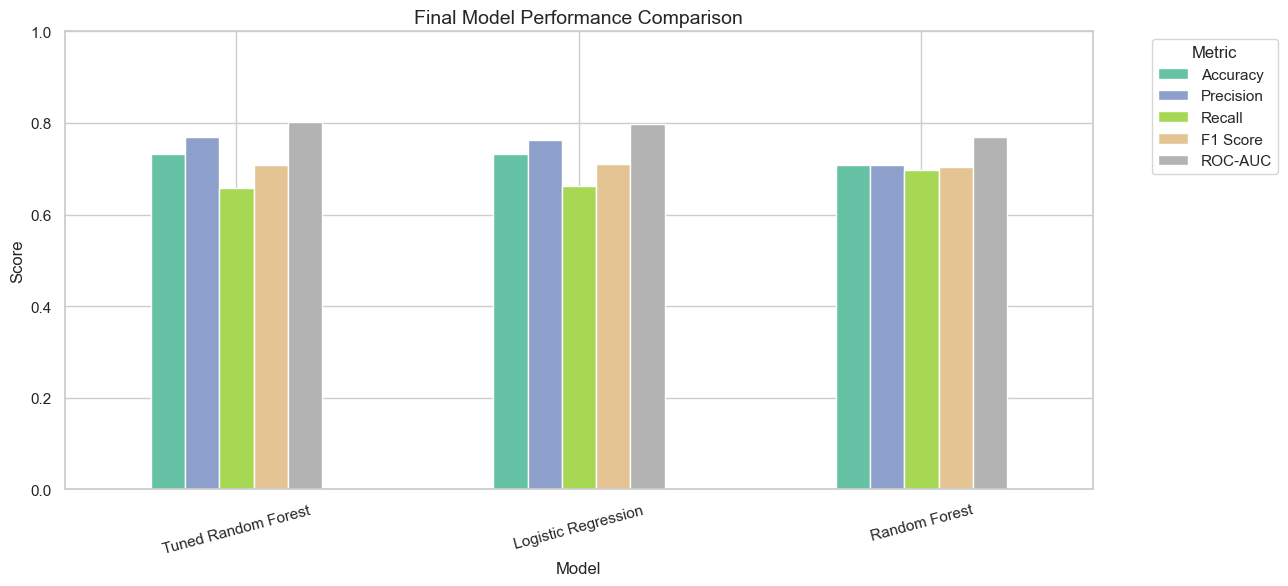

Best model based on ROC-AUC: Tuned Random Forest


In [39]:
# Final comparison chart.
final_comparison_plot_df = final_evaluation_df.set_index("Model")[metric_columns]

final_comparison_plot_df.plot(kind="bar", figsize=(13, 6), colormap="Set2")
plt.title("Final Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

best_model_name = final_evaluation_df.iloc[0]["Model"]
print(f"Best model based on ROC-AUC: {best_model_name}")


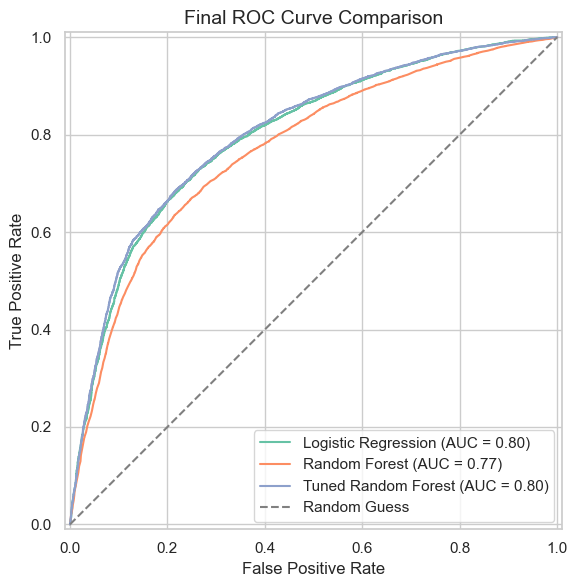

Insight: The best model usually has the highest curve and highest ROC-AUC score.


In [40]:
# Final ROC curve comparison.
plt.figure(figsize=(9, 6))
for model_name, model in trained_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=model_name, ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
plt.title("Final ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

print("Insight: The best model usually has the highest curve and highest ROC-AUC score.")


# 13. Feature Importance

Feature importance explains which inputs the Random Forest used most. This helps with interpretation, but it does not prove medical causation.


,Feature,Importance
3,ap_hi,0.221
7,mean_arterial_pressure,0.193
17,bp_category_Hypertension Stage 2,0.122
4,ap_lo,0.101
0,age_years,0.086
6,pulse_pressure,0.073
10,cholesterol_Well Above Normal,0.050
9,cholesterol_Normal,0.037
18,bp_category_Normal,0.026
16,bp_category_Hypertension Stage 1,0.024


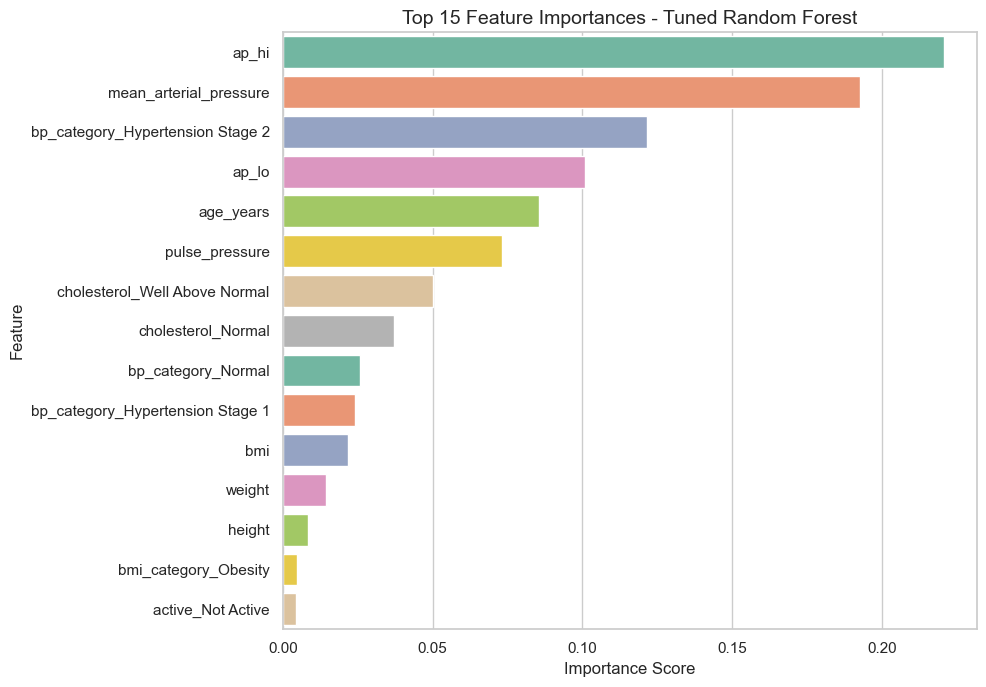

Insight: Blood pressure, age, BMI, and cholesterol-related features are often important in this dataset.


In [41]:
# Use tuned Random Forest if available, otherwise use baseline Random Forest.
importance_model_name = "Tuned Random Forest" if "Tuned Random Forest" in trained_models else "Random Forest"
importance_model = trained_models[importance_model_name]

# Extract fitted preprocessing and model steps.
fitted_preprocessor = importance_model.named_steps["preprocess"]
fitted_rf_model = importance_model.named_steps["model"]

# Get feature names after preprocessing.
feature_names = fitted_preprocessor.get_feature_names_out()
feature_names = [name.replace("num__", "").replace("cat__", "") for name in feature_names]

# Random Forest feature importance values.
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": fitted_rf_model.feature_importances_,
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(20))

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df.head(15), x="Importance", y="Feature", palette="Set2")
plt.title(f"Top 15 Feature Importances - {importance_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("Insight: Blood pressure, age, BMI, and cholesterol-related features are often important in this dataset.")


# 14. Save the Final Trained Model

We save the best model using `joblib`. The saved object is the full pipeline, so it includes preprocessing and the trained classifier together.


In [42]:
# Select the best model using ROC-AUC.
best_model_name = final_evaluation_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]["Model"]
best_model = trained_models[best_model_name]

# Save inside the models folder.
MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)
model_path = MODEL_DIR / "heart_disease_best_model.joblib"
joblib.dump(best_model, model_path)

print(f"Best model: {best_model_name}")
print(f"Model saved to: {model_path}")


Best model: Tuned Random Forest
Model saved to: /Users/jeevraj/Desktop/AI Cardiovascular Disease Analysis/models/heart_disease_best_model.joblib


In [43]:
# Test loading the saved model.
loaded_model = joblib.load(model_path)

# Predict one example from the test set.
example_patient = X_test.iloc[[0]]
example_actual = y_test.iloc[0]
example_prediction = loaded_model.predict(example_patient)[0]
example_probability = loaded_model.predict_proba(example_patient)[0, 1]

print("Example prediction using the saved model")
print("Actual value:", example_actual)
print("Predicted value:", example_prediction)
print(f"Predicted probability of disease: {example_probability:.3f}")
display(example_patient)


Example prediction using the saved model
Actual value: 1
Predicted value: 1
Predicted probability of disease: 0.867


,age_years,height,weight,ap_hi,ap_lo,bmi,pulse_pressure,mean_arterial_pressure,gender,cholesterol,gluc,smoke,alco,active,bp_category,bmi_category
52561,51.900,164,84.000,150,90,31.231,60,110.000,Female,Above Normal,Normal,No,No,Active,Hypertension Stage 2,Obesity


# 15. Final Conclusion

This section summarizes the complete project using actual model results from the notebook.


In [44]:
# Create a dynamic conclusion using actual results from this notebook.
best_row = final_evaluation_df.sort_values(by="ROC-AUC", ascending=False).iloc[0]
top_features_text = ", ".join(importance_df.head(5)["Feature"].tolist())

conclusion_lines = [
    "## Final Project Summary",
    "",
    "### Key Findings from EDA",
    "- The target variable is almost balanced, which is helpful for model training.",
    "- Older patients generally show a higher cardiovascular disease rate.",
    "- Blood pressure features show a strong relationship with the target.",
    "- Higher cholesterol levels appear related to higher disease rate.",
    "- BMI and lifestyle variables provide additional useful information.",
    "",
    "### Important Features",
    f"The top model features include: **{top_features_text}**.",
    "",
    "### Best Performing Model",
    f"The best model based on ROC-AUC is **{best_row['Model']}**.",
    "",
    "| Metric | Score |",
    "|---|---:|",
    f"| Accuracy | {best_row['Accuracy']:.4f} |",
    f"| Precision | {best_row['Precision']:.4f} |",
    f"| Recall | {best_row['Recall']:.4f} |",
    f"| F1 Score | {best_row['F1 Score']:.4f} |",
    f"| ROC-AUC | {best_row['ROC-AUC']:.4f} |",
    "",
    "### Overall Project Summary",
    "This notebook followed a full Machine Learning workflow: data loading, data understanding, cleaning, outlier handling, EDA, feature engineering, preprocessing, model training, evaluation, cross-validation, hyperparameter tuning, feature importance, and saving the final model.",
    "",
    "### Possible Future Improvements",
    "- Try XGBoost, LightGBM, CatBoost, SVM, or neural networks.",
    "- Add more medical features such as family history, medication, diet, and exercise frequency.",
]

display(Markdown("\n".join(conclusion_lines)))


## Final Project Summary

### Key Findings from EDA
- The target variable is almost balanced, which is helpful for model training.
- Older patients generally show a higher cardiovascular disease rate.
- Blood pressure features show a strong relationship with the target.
- Higher cholesterol levels appear related to higher disease rate.
- BMI and lifestyle variables provide additional useful information.

### Important Features
The top model features include: **ap_hi, mean_arterial_pressure, bp_category_Hypertension Stage 2, ap_lo, age_years**.

### Best Performing Model
The best model based on ROC-AUC is **Tuned Random Forest**.

| Metric | Score |
|---|---:|
| Accuracy | 0.7328 |
| Precision | 0.7685 |
| Recall | 0.6582 |
| F1 Score | 0.7091 |
| ROC-AUC | 0.8023 |

### Overall Project Summary
This notebook followed a full Machine Learning workflow: data loading, data understanding, cleaning, outlier handling, EDA, feature engineering, preprocessing, model training, evaluation, cross-validation, hyperparameter tuning, feature importance, and saving the final model.

### Possible Future Improvements
- Try XGBoost, LightGBM, CatBoost, SVM, or neural networks.
- Add more medical features such as family history, medication, diet, and exercise frequency.